In [1]:
import torch
import hydra
from omegaconf import DictConfig, OmegaConf
from solo.args.pretrain import parse_cfg
from solo.methods.ta import BYOLWithTA
from hydra import compose, initialize

from pytorch_lightning import seed_everything

from solo.methods import METHODS

from solo.data.pretrain_dataloader import (
    FullTransformPipeline,
    NCropAugmentation,
    build_transform_pipeline,
    prepare_dataloader,
    prepare_datasets,
)

/home/adondera/projects/manifold-ta/venv/lib/python3.9/site-packages/pl_bolts/models/self_supervised/amdim/amdim_module.py:35: UnderReviewWarning: The feature generate_power_seq is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  "lr_options": generate_power_seq(LEARNING_RATE_CIFAR, 11),
/home/adondera/projects/manifold-ta/venv/lib/python3.9/site-packages/pl_bolts/models/self_supervised/amdim/amdim_module.py:93: UnderReviewWarning: The feature FeatureMapContrastiveTask is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  contrast

Global seed set to 5


BYOLWithTA(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): Identity()
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        

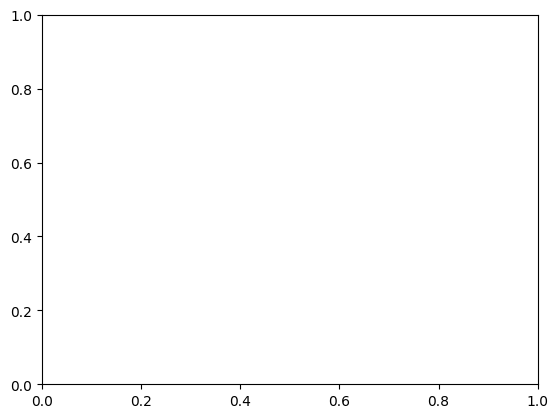

In [2]:
with initialize(version_base=None, config_path="scripts/pretrain/cifar"):
    cfg = compose(config_name="byol-ta.yaml")

OmegaConf.set_struct(cfg, False)
cfg = parse_cfg(cfg)
seed_everything(cfg.seed)
model = METHODS[cfg.method](cfg)
model.eval()

In [3]:
pipelines = []
for aug_cfg in cfg.augmentations:
    pipelines.append(
        NCropAugmentation(
            build_transform_pipeline(cfg.data.dataset, aug_cfg), aug_cfg.num_crops
        )
    )
transform = FullTransformPipeline(pipelines)

if cfg.debug_augmentations:
    print("Transforms:")
    print(transform)

train_dataset = prepare_datasets(
    cfg.data.dataset,
    transform,
    train_data_path=cfg.data.train_path,
    data_format=cfg.data.format,
    no_labels=cfg.data.no_labels,
    data_fraction=cfg.data.fraction,
)
train_loader = prepare_dataloader(
    train_dataset, batch_size=cfg.optimizer.batch_size, num_workers=cfg.data.num_workers
)

Files already downloaded and verified


In [4]:
train_loader_iterator = iter(train_loader)

In [5]:
img_batch = next(train_loader_iterator)
with torch.no_grad():
    model_inputs = img_batch[1][0]
output = model(model_inputs)

In [11]:
def get_projector_output(model, batch):
    out = super(type(model), model).training_step(batch, 0)
    student_z = model.projector(out["feats"][0])
    teacher_z = model.momentum_projector(out["momentum_feats"][1])
    return [student_z, teacher_z]

def test_attention(model, queries, keys, values):
    student_queries = model.query_matrix(queries)
    student_keys = model.key_matrix(keys)
    student_values = model.value_matrix(values)
    d = student_queries.shape[-1]
    student_weights = torch.nn.functional.softmax(torch.mm(student_queries, student_keys.transpose(0,1)) / np.sqrt(d), dim=-1)
    student_y = torch.mm(student_weights, student_values)
    return student_y

In [15]:
proj_features = get_projector_output(model, img_batch)

queries = proj_features[0]
keys = torch.cat(proj_features)
values = torch.cat(proj_features)

model_output = test_attention(model, queries, keys, values)

In [16]:
true_output, _ = torch.nn.functional.multi_head_attention_forward(
            queries,
            keys,
            values,
            embed_dim_to_check=256,
            num_heads=1,
            in_proj_weight=None,
            in_proj_bias=None,
            bias_k=None,
            bias_v=None,
            add_zero_attn=False,
            dropout_p=0.0,
            out_proj_bias=torch.zeros(256),
            out_proj_weight=torch.eye(256),
            training=False,
            key_padding_mask=None,
            need_weights=True,
            attn_mask=None,
            use_separate_proj_weight=True,
            q_proj_weight=model.query_matrix.weight,
            k_proj_weight=model.key_matrix.weight,
            v_proj_weight=model.value_matrix.weight,
            static_k=None,
            static_v=None,
        )

In [17]:
torch.allclose(true_output, model_output)

True